# 05. Auditing the characterisation output

The SEM-EDS report states 75.52 wt% Zn on the zinc-contacted peel and 60.96 wt%
Mn on the manganese-contacted peel. Those numbers would normally be quoted as
confirmation that both metals were taken up.

This notebook checks them against three things that do not depend on the
instrument's own labels: whether the reported compositions sum correctly,
whether the observed peak positions match the X-ray emission lines of the
elements claimed, and whether the surface loadings are consistent with the
uptake measured independently by AAS.

Two of the three checks fail for manganese.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adsorption import concentration, uptake

eds = pd.read_csv("data/eds_composition.csv")
peaks = pd.read_csv("data/eds_peaks.csv")
lines = pd.read_csv("data/xray_lines.csv")

wide = eds.pivot_table(index="sample", columns="element",
                       values="weight_pct", observed=False)
wide = wide.reindex(["raw_peel", "after_Zn", "after_Mn"])
wide["SUM"] = wide.sum(axis=1)
print(wide.round(2).to_string())
print()
for sample, total in wide["SUM"].items():
    flag = "" if abs(total - 100) < 0.5 else "   <-- does not sum to 100%"
    print(f"{sample:10s} total = {total:6.2f}%{flag}")

element    Al      C   Fe     Mn   Na      O     Si     Zn     SUM
sample                                                            
raw_peel  8.3   4.50  4.3    NaN  2.4  20.26  60.24    NaN  100.00
after_Zn  NaN    NaN  NaN    NaN  NaN  24.48    NaN  75.52  100.00
after_Mn  NaN  18.34  NaN  60.96  NaN  25.67    NaN    NaN  104.97

raw_peel   total = 100.00%
after_Zn   total = 100.00%
after_Mn   total = 104.97%   <-- does not sum to 100%


EDS weight percentages are normalised to the elements the operator selects, so
they should sum to 100% by construction. The manganese sample sums to 104.97%,
which means the reported table cannot be reconciled without the original
instrument file.

The raw peel is also worth a look: 60.24% silicon and only 4.50% carbon is not
a plant material. The analysed spot was dominated by something mineral, and the
weak sharp FTIR band near 3694 cm-1 that is typical of Al-OH in clay is
consistent with that.

In [2]:
# Check 1: do the observed peak positions match the elements claimed?
READING_UNCERTAINTY = 0.1   # keV, from reading values off the printed axis

print("Observed peaks, matched against tabulated X-ray lines\n")
for _, pk in peaks.iterrows():
    near = lines.copy()
    near["gap"] = (near.energy_keV - pk.observed_keV).abs()
    near = near[near.gap <= READING_UNCERTAINTY].sort_values("gap")
    labels = ", ".join(f"{r.element} {r.line} ({r.energy_keV:.3f} keV)"
                       for _, r in near.iterrows())
    print(f"{pk['sample']}: peak at {pk.observed_keV:.2f} keV, "
          f"labelled {pk.label_in_report}")
    print(f"   lines within +/-{READING_UNCERTAINTY} keV: "
          f"{labels if labels else 'none'}")
    if not labels:
        best = lines.assign(gap=(lines.energy_keV - pk.observed_keV).abs()) \
                    .sort_values("gap").iloc[0]
        print(f"   nearest line of any element: {best.element} {best.line} "
              f"({best.energy_keV:.3f} keV), {best.gap:.2f} keV away")
    print()

Observed peaks, matched against tabulated X-ray lines

after_Zn: peak at 0.90 keV, labelled Zn
   lines within +/-0.1 keV: none
   nearest line of any element: Zn La (1.012 keV), 0.11 keV away

after_Zn: peak at 2.25 keV, labelled Zn
   lines within +/-0.1 keV: S Ka (2.307 keV)

after_Mn: peak at 3.70 keV, labelled Mn
   lines within +/-0.1 keV: Ca Ka (3.692 keV)



The zinc peak was read off a printed axis as about 0.9 keV. Zn Lα at 1.012 keV
is the nearest line of any element, 0.11 keV away, which is just outside the
+/-0.1 keV window used above and well within the uncertainty of reading a
position off a figure. Zinc is present in the analysed region.

One caveat belongs with it. Na Kα sits at 1.041 keV and the raw peel contained
2.40% Na, so the two cannot be separated by peak position alone at this
resolution.

The second peak labelled Zn is the problem. At 2.2 to 2.3 keV there is no zinc
line at all. Zn Kα is at 8.639 keV, far outside. S Kα at 2.307 keV is the
obvious candidate, and residual sulfate from the zinc sulfate salt would
explain it.

The manganese peak is worse. The tallest peak in that spectrum sits at 3.7 keV,
which is Ca Kα at 3.692, entirely plausible in plant tissue. Manganese emits at
5.899 and 6.490 keV.

In [3]:
# Check 2: were the expected Mn lines inside the displayed range?
DISPLAY_MAX = 7.0   # keV, the upper limit of the printed spectrum

mn_lines = lines[(lines.element == "Mn") & (lines.line.isin(["Ka", "Kb"]))]
print(f"Spectrum displayed from 0 to {DISPLAY_MAX} keV.\n")
for _, r in mn_lines.iterrows():
    inside = "inside the displayed range" if r.energy_keV <= DISPLAY_MAX \
        else "outside the displayed range"
    print(f"  Mn {r.line} at {r.energy_keV:.3f} keV: {inside}")
print()
print("Both Mn K lines fall inside the printed range and neither is visible in")
print("the spectrum, while 60.96 wt% Mn is reported. The presence of manganese")
print("in the analysed region is therefore not confirmed by this spectrum.")

Spectrum displayed from 0 to 7.0 keV.

  Mn Ka at 5.899 keV: inside the displayed range
  Mn Kb at 6.490 keV: inside the displayed range

Both Mn K lines fall inside the printed range and neither is visible in
the spectrum, while 60.96 wt% Mn is reported. The presence of manganese
in the analysed region is therefore not confirmed by this spectrum.


In [4]:
# Check 3: is the reported surface loading consistent with the AAS uptake?
raw = pd.read_csv("data/aas_readings.csv")
CONTROL = {m: float(concentration(
    raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0],
    raw.loc[(raw.series == "control") & (raw.metal == m), "dilution_factor"].iloc[0]))
    for m in ["Mn", "Zn"]}

ref = raw[(raw.series == "concentration") & (raw.nominal_C0_mg_L == 400)]
rows = []
for _, r in ref.iterrows():
    q = float(uptake(CONTROL[r.metal],
                     concentration(r.reading_mg_L, r.dilution_factor),
                     r.volume_L, r.mass_g))
    loading_wt_pct = q / 1000.0 * 100.0          # mg/g -> weight %
    reported = float(eds[(eds["sample"] == f"after_{r.metal}") &
                         (eds.element == r.metal)]["weight_pct"].iloc[0])
    rows.append({"metal": r.metal,
                 "AAS uptake (mg/g)": round(q, 2),
                 "implied loading (wt%)": round(loading_wt_pct, 3),
                 "EDS reported (wt%)": reported,
                 "ratio": round(reported / loading_wt_pct)})

print(pd.DataFrame(rows).to_string(index=False))
print()
print("The EDS figures are two to three orders of magnitude above the bulk")
print("loading measured by AAS. EDS samples a few micrometres of one selected")
print("spot and normalises to the elements chosen, so it describes a local")
print("feature, not the material. It is qualitative evidence of presence at")
print("best, and cannot be used as a capacity measurement.")

metal  AAS uptake (mg/g)  implied loading (wt%)  EDS reported (wt%)  ratio
   Mn               1.37                  0.137               60.96    446
   Zn               2.80                  0.280               75.52    270

The EDS figures are two to three orders of magnitude above the bulk
loading measured by AAS. EDS samples a few micrometres of one selected
spot and normalises to the elements chosen, so it describes a local
feature, not the material. It is qualitative evidence of presence at
best, and cannot be used as a capacity measurement.


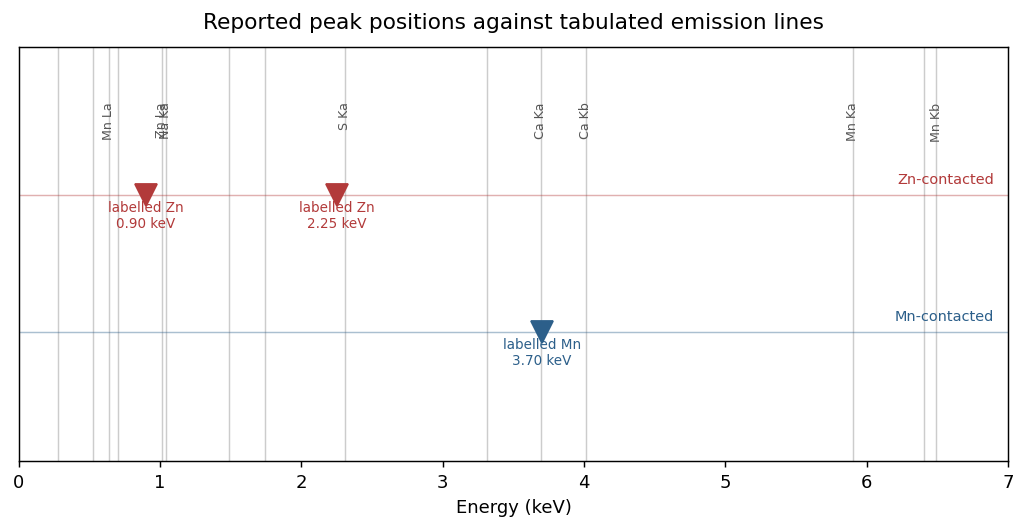

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.set_xlim(0, 7)
shown = lines[lines.energy_keV <= 7.0]
for _, r in shown.iterrows():
    ax.axvline(r.energy_keV, color="#cccccc", lw=0.8, zorder=1)
    if r.element in ["Zn", "Mn", "Ca", "S", "Na"]:
        ax.text(r.energy_keV, 0.97, f"{r.element} {r.line}", rotation=90,
                fontsize=7, ha="center", va="top", color="#555555")

for _, pk in peaks.iterrows():
    colour = "#b23a3a" if pk["sample"] == "after_Zn" else "#2c5f8a"
    y = 0.72 if pk["sample"] == "after_Zn" else 0.35
    ax.plot([pk.observed_keV], [y], "v", color=colour, ms=12, zorder=3)
    ax.text(pk.observed_keV, y - 0.09,
            f"labelled {pk.label_in_report}\n{pk.observed_keV:.2f} keV",
            ha="center", fontsize=7.5, color=colour)

ax.axhline(0.72, color="#b23a3a", lw=0.8, alpha=0.4)
ax.axhline(0.35, color="#2c5f8a", lw=0.8, alpha=0.4)
ax.text(6.9, 0.75, "Zn-contacted", ha="right", fontsize=8, color="#b23a3a")
ax.text(6.9, 0.38, "Mn-contacted", ha="right", fontsize=8, color="#2c5f8a")
ax.set_ylim(0, 1.12)
ax.set_yticks([])
ax.set_xlabel("Energy (keV)")
ax.set_title("Reported peak positions against tabulated emission lines",
             pad=10)
fig.tight_layout()

## FTIR: which changes are larger than the instrument can resolve

The spectra were recorded at 8 cm-1 resolution. A band position cannot be
compared meaningfully against a shift of the same size as that resolution.

In [6]:
ftir = pd.read_csv("data/ftir_bands.csv")
RESOLUTION = 8.0

ftir["shift_Zn"] = ftir.after_Zn_cm1 - ftir.raw_cm1
ftir["shift_Mn"] = ftir.after_Mn_cm1 - ftir.raw_cm1

def verdict(row):
    if pd.isna(row.raw_cm1):
        return "band APPEARS after contact"
    if pd.isna(row.after_Zn_cm1) and pd.isna(row.after_Mn_cm1):
        return "band LOST after contact"
    shifts = [s for s in [row.shift_Zn, row.shift_Mn] if not pd.isna(s)]
    biggest = max(abs(s) for s in shifts)
    if biggest <= RESOLUTION:
        return "within resolution, not interpretable"
    if biggest <= 2 * RESOLUTION:
        return "marginal (1-2x resolution)"
    return "larger than 2x resolution"

ftir["verdict"] = ftir.apply(verdict, axis=1)
print(ftir[["raw_cm1", "after_Zn_cm1", "after_Mn_cm1", "shift_Zn",
            "shift_Mn", "verdict"]].to_string(index=False))
print()
counts = ftir.verdict.value_counts()
print(counts.to_string())

 raw_cm1  after_Zn_cm1  after_Mn_cm1  shift_Zn  shift_Mn                              verdict
  3694.0        3690.0        3698.0      -4.0       4.0 within resolution, not interpretable
  3276.0        3284.0        3291.0       8.0      15.0           marginal (1-2x resolution)
  2922.0        2900.0        2919.0     -22.0      -3.0            larger than 2x resolution
  1737.0           NaN           NaN       NaN       NaN              band LOST after contact
  1636.0        1636.0        1636.0       0.0       0.0 within resolution, not interpretable
     NaN        1420.0        1420.0       NaN       NaN           band APPEARS after contact
  1364.0        1334.0        1364.0     -30.0       0.0            larger than 2x resolution
  1234.0        1245.0        1241.0      11.0       7.0           marginal (1-2x resolution)
  1148.0        1148.0        1148.0       0.0       0.0 within resolution, not interpretable
  1074.0        1074.0           NaN       0.0       NaN wit

Nine of the eleven comparable bands shift by no more than twice the resolution,
so they carry little or no information. Two are larger: the aliphatic C-H band
moves 22 cm-1 and the 1364 cm-1 band moves 30 cm-1, both only in the
zinc-contacted sample. Neither has a single unambiguous interpretation on its
own, and the spectra were not normalised, so they are noted rather than built
on.

The two changes that are interpretable are qualitative rather than positional:
the ester/carboxyl C=O band at 1737 cm-1 is no longer resolved after contact
with either metal, and a band at 1420 cm-1 appears where none was observed
before.

That pairing is consistent with carboxyl groups interacting with metal cations.
It is also consistent with ester groups simply hydrolysing in solution, which
needs no metal at all. FTIR alone cannot separate the two, and the spectra were
not normalised, so the intensity differences between samples are not
interpreted either.

In [7]:
changed = ftir[ftir.verdict.str.contains("APPEARS|LOST")]
print(changed[["raw_cm1", "after_Zn_cm1", "after_Mn_cm1",
               "assignment"]].to_string(index=False))
print()
print("Two qualitative changes, both in the carbonyl/carboxyl region.")
print("That is the whole of the interpretable FTIR evidence.")

 raw_cm1  after_Zn_cm1  after_Mn_cm1                                               assignment
  1737.0           NaN           NaN C=O of ester or carboxylic groups (hemicellulose pectin)
     NaN        1420.0        1420.0          Symmetric carboxylate stretching or CH2 bending

Two qualitative changes, both in the carbonyl/carboxyl region.
That is the whole of the interpretable FTIR evidence.


## SEM annotations: a consistency check on the micrographs

Horizontal field width is the real width of the imaged area. It is fixed by the
display width divided by the magnification, so `HFW x magnification` is a
constant for a given instrument, and HFW must **fall** as magnification rises.

The values printed on these micrographs do the opposite.

In [8]:
sem = pd.read_csv("data/sem_parameters.csv")

frames = []
for sample, g in sem.groupby("sample", sort=False):
    g = g.sort_values("magnification").copy()
    base = g.iloc[0]
    g["expected_hfw_um"] = base.hfw_um * base.magnification / g.magnification
    g["hfw_x_mag"] = g.hfw_um * g.magnification
    g["scale_as_pct_of_hfw"] = g.scale_label_um / g.hfw_um * 100
    frames.append(g)
sem = pd.concat(frames)

print(sem[["sample", "magnification", "hfw_um", "expected_hfw_um",
           "hfw_x_mag", "scale_label_um",
           "scale_as_pct_of_hfw"]].round(1).to_string(index=False))
print()

for sample, g in sem.groupby("sample", sort=False):
    g = g.sort_values("magnification")
    drift = g.hfw_x_mag.max() / g.hfw_x_mag.min()
    falls = bool((g.hfw_um.diff().dropna() < 0).all())
    verdict = "direction correct" if falls else "HFW DOES NOT FALL with magnification"
    print(f"{sample:10s} HFW x magnification varies by a factor of "
          f"{drift:.2f} across the set ({verdict})")

  sample  magnification  hfw_um  expected_hfw_um  hfw_x_mag  scale_label_um  scale_as_pct_of_hfw
raw_peel           8000     125            125.0    1000000              50                 40.0
raw_peel           9000     126            111.1    1134000             100                 79.4
raw_peel          10000     130            100.0    1300000              20                 15.4
after_Zn           8000     120            120.0     960000             100                 83.3
after_Zn           9000     122            106.7    1098000              50                 41.0
after_Zn          10000     125             96.0    1250000              20                 16.0
after_Mn           8000     110            110.0     880000              10                  9.1
after_Mn           9000     110             97.8     990000              10                  9.1
after_Mn          10000     120             88.0    1200000              10                  8.3

raw_peel   HFW x magnificatio

In [9]:
# Same nominal magnification, different scale bars
print("Scale bar printed at each magnification:")
pivot = sem.pivot_table(index="magnification", columns="sample",
                        values="scale_label_um", observed=False)
print(pivot.to_string())
print()
print("At 8,000x the three samples carry 50, 100 and 10 micrometre bars.")
print("At the same magnification on the same instrument they should match.")
print()

print("Imaging conditions:")
cond = sem.groupby("sample", sort=False)[["hv_kV", "pressure_Pa"]].agg(
    lambda x: sorted(set(x)))
print(cond.to_string())
print()
print("The Mn images were taken at 15 kV and 90 Pa, the raw and Zn images at")
print("20 kV and 70 Pa. Accelerating voltage changes the interaction volume,")
print("so apparent texture differences between the Mn set and the others are")
print("not comparable like for like.")

Scale bar printed at each magnification:
sample         after_Mn  after_Zn  raw_peel
magnification                              
8000               10.0     100.0      50.0
9000               10.0      50.0     100.0
10000              10.0      20.0      20.0

At 8,000x the three samples carry 50, 100 and 10 micrometre bars.
At the same magnification on the same instrument they should match.

Imaging conditions:
         hv_kV pressure_Pa
sample                    
raw_peel  [20]        [70]
after_Zn  [20]        [70]
after_Mn  [15]        [90]

The Mn images were taken at 15 kV and 90 Pa, the raw and Zn images at
20 kV and 70 Pa. Accelerating voltage changes the interaction volume,
so apparent texture differences between the Mn set and the others are
not comparable like for like.


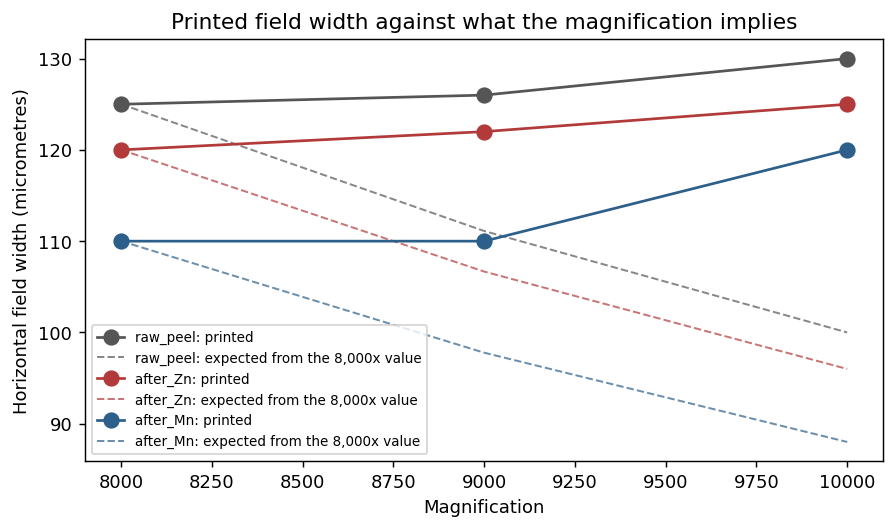

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.2))
colours = {"raw_peel": "#555555", "after_Zn": "#b23a3a", "after_Mn": "#2c5f8a"}
for sample, g in sem.groupby("sample", sort=False):
    g = g.sort_values("magnification")
    ax.plot(g.magnification, g.hfw_um, "o-", color=colours[sample],
            lw=1.5, ms=8, label=f"{sample}: printed")
    ax.plot(g.magnification, g.expected_hfw_um, "--", color=colours[sample],
            lw=1.1, alpha=0.7,
            label=f"{sample}: expected from the 8,000x value")
ax.set_xlabel("Magnification")
ax.set_ylabel("Horizontal field width (micrometres)")
ax.set_title("Printed field width against what the magnification implies")
ax.legend(fontsize=7.5)
fig.tight_layout()

Printed field width fails to fall with magnification in any of the three sets.
It rises in the raw and zinc sets and is flat then rising in the manganese set,
when it must fall throughout. The quantity `HFW x magnification`, which should
be constant, drifts by a factor of 1.3 or more. The scale bars disagree with the field widths as well, and differ between
samples at the same nominal magnification.

No dimension can be measured from these micrographs. The SEM images support a
qualitative statement, that the surface looks more aggregated after metal
contact and drying, and nothing beyond it. Particle sizes, pore sizes and
surface areas are all unavailable, which is one reason no capacity claim rests
on the imaging.

## Conclusions

| Check | Zn(II) | Mn(II) |
|---|---|---|
| Composition sums to 100% | yes | no, 104.97% |
| Peak position matches the element | yes for the 0.9 keV peak; the second peak labelled Zn matches S Kα, not Zn | no, the tallest peak matches Ca Kα and both Mn K lines are absent from the displayed range |
| Loading consistent with AAS | no, about 270x higher | no, about 450x higher |

- Zinc is present in the analysed region. The second peak labelled Zn is more
  likely residual sulfate.
- Manganese is **not confirmed** by the available spectrum, despite 60.96 wt%
  appearing in the report.
- The weight percentages describe one selected spot a few micrometres deep, not
  the bulk material, and cannot support a capacity claim.
- FTIR supports altered oxygen-containing functional groups after metal
  contact, and nothing more specific than that. No binding mechanism is
  established.
- The SEM annotations are internally inconsistent: field width rises with
  magnification instead of falling, and the scale bars do not agree with it.
  The images are qualitative only.

The instrument produced a number with an element label attached. Checking the
label against the physics is what this notebook is for, and recommendation 9 in
the thesis asks for full EDS reports covering 0 to 10 keV so that it can be
done properly next time.